In [1]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [4]:
from main import load_batch, process_data_batch, train_model, plot_strokes
from os import listdir
from os.path import isfile, join

process: ./batches/batch0.pt


d:\projects\Diploma\features.py:408: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(np.vstack([xs - cx, ys - cy]))
c:\Users\ivan\.conda\envs\Diploma\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\ivan\.conda\envs\Diploma\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Epoch   0 | Train Loss: 0.79045 | Train Acc:  36.41% | Val Loss: 0.79422 | Val Acc: 35.71%
Epoch  10 | Train Loss: 0.26025 | Train Acc:  72.72% | Val Loss: 0.30060 | Val Acc: 69.39%
Epoch  20 | Train Loss: 0.23582 | Train Acc:  72.68% | Val Loss: 0.26184 | Val Acc: 69.18%
Epoch  30 | Train Loss: 0.22595 | Train Acc:  72.81% | Val Loss: 0.25691 | Val Acc: 69.71%
Epoch  40 | Train Loss: 0.21847 | Train Acc:  74.78% | Val Loss: 0.24550 | Val Acc: 71.73%
Epoch  50 | Train Loss: 0.21360 | Train Acc:  76.36% | Val Loss: 0.23451 | Val Acc: 74.07%
Epoch  60 | Train Loss: 0.20402 | Train Acc:  78.86% | Val Loss: 0.22995 | Val Acc: 75.56%
Epoch  70 | Train Loss: 0.19702 | Train Acc:  79.67% | Val Loss: 0.22419 | Val Acc: 76.83%
Epoch  80 | Train Loss: 0.18891 | Train Acc:  80.98% | Val Loss: 0.21638 | Val Acc: 78.11%
Epoch  90 | Train Loss: 0.18307 | Train Acc:  82.26% | Val Loss: 0.20989 | Val Acc: 79.60%
Epoch 100 | Train Loss: 0.18417 | Train Acc:  81.99% | Val Loss: 0.21234 | Val Acc: 79.28%

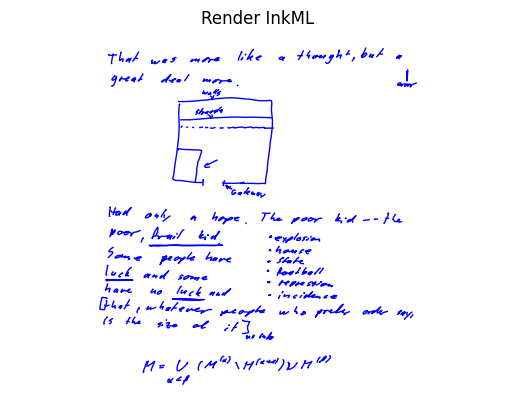

process: ./batches/batch1.pt


d:\projects\Diploma\features.py:408: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(np.vstack([xs - cx, ys - cy]))
c:\Users\ivan\.conda\envs\Diploma\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\ivan\.conda\envs\Diploma\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Epoch   0 | Train Loss: 0.46646 | Train Acc:  75.57% | Val Loss: 0.46041 | Val Acc: 76.99%
Epoch  10 | Train Loss: 0.24318 | Train Acc:  77.07% | Val Loss: 0.23249 | Val Acc: 78.12%
Epoch  20 | Train Loss: 0.22694 | Train Acc:  77.21% | Val Loss: 0.21771 | Val Acc: 78.22%
Epoch  30 | Train Loss: 0.22060 | Train Acc:  77.19% | Val Loss: 0.21149 | Val Acc: 78.22%
Epoch  40 | Train Loss: 0.21489 | Train Acc:  77.21% | Val Loss: 0.20822 | Val Acc: 78.22%


KeyboardInterrupt: 

In [3]:
path = './batches/'
files = [f for f in listdir(path) if (isfile(join(path, f)) and f.endswith('.pt') and not f.endswith('_proc.pt'))]
model=None

for file in files:
    print("process: "+path+file)
    strokes, true_y = load_batch(path+file, device)
    data=process_data_batch(strokes, true_y, batch=path+file, device=device)
    data = data.to(device)
    clasified, model=train_model(data, device)

    plot_strokes(strokes[0], clasified)